In [5]:
import matplotlib.pyplot as plt
import shap
from src.data_processing.process_soil import process_soil
import pandas as pd
import joblib

In [8]:
df = pd.read_csv("../data/raw/soil_raw.csv")
df_processed = process_soil(df)

In [10]:
model = joblib.load("../models/xgboost_soil.model")


In [11]:
target = "Потенциал урожая пшеницы (ц/га)"
X = df_processed.drop(columns=[target])
y = df_processed[target]

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
y_pred = model.predict(X_test)

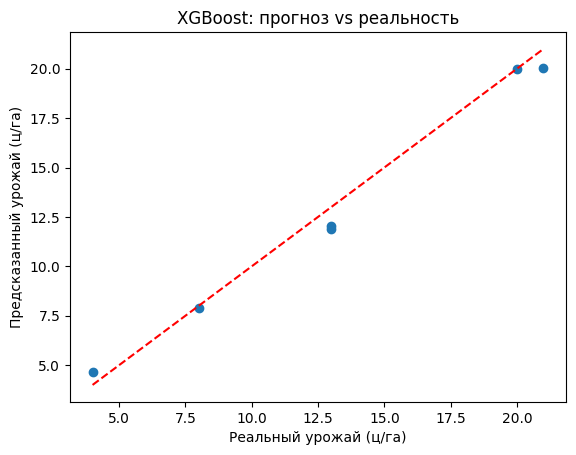

In [14]:
plt.scatter(y_test, y_pred)
plt.xlabel("Реальный урожай (ц/га)")
plt.ylabel("Предсказанный урожай (ц/га)")
plt.title("XGBoost: прогноз vs реальность")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # диагональ
plt.show()

In [15]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

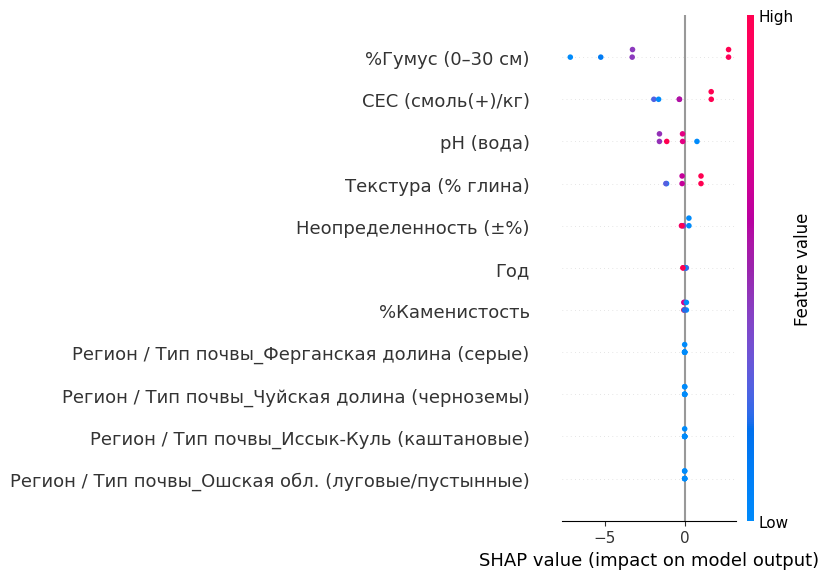

In [16]:
shap.summary_plot(shap_values, X_test)

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Оценка точности модели ===")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R²: {r2:.3f}")

=== Оценка точности модели ===
RMSE: 0.778
MAE: 0.650
R²: 0.983
